In [ ]:
-- For summarization what we do we delete some previous messages and make a 
   summarization report of that messagea

In [9]:
from langgraph.graph import StateGraph, START, MessagesState,END
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain.messages import RemoveMessage
import os

In [10]:
load_dotenv()
api_key = os.getenv("OPENROUTER_API_KEY")

In [11]:
llm = ChatOpenAI(
    model="deepseek/deepseek-r1-0528:free",
    api_key=api_key,
    base_url="https://openrouter.ai/api/v1",
    temperature=0
)

In [18]:
def chat(state: MessagesState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 4
    if len(msgs) > 10:
        to_remove = msgs[:4]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

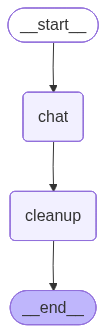

In [19]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", END)


graph = builder.compile(checkpointer=InMemorySaver())
graph

In [20]:
config = {"configurable": {"thread_id": "t1"}}

In [21]:
# Run multiple times 
graph.invoke({"messages": [{"role": "user", "content": "Hi, I am yug"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain workflow"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Short term memory"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='Now explain workflow', additional_kwargs={}, response_metadata={}, id='3c8b5550-2eaa-49bd-b5df-16283e298d2b'),
  AIMessage(content='Let\'s break down the **LangGraph workflow** step-by-step using a practical example. We\'ll create an agent that decides whether to answer a question directly or perform a web search first. Here\'s how the workflow operates:\n\n---\n\n### **Workflow Anatomy**\n```mermaid\ngraph LR\n    A[Start] --> B(Decide Action)\n    B -->|Direct Answer| C[Generate Answer]\n    B -->|Need Search| D[Web Search]\n    D --> E[Generate Answer]\n    C --> F[END]\n    E --> F[END]\n```\n\n---\n\n### **Step-by-Step Implementation**\n\n#### **1. Define State Schema**\nThe shared memory passed between nodes:\n```python\nfrom typing import TypedDict, Annotated\nfrom langgraph.graph import StateGraph\n\nclass AgentState(TypedDict):\n    question: str\n    search_needed: bool  # Decision from router\n    search_result: str   # Filled by search to

In [ ]:
# Total Messages was 14 which was more then 10 so it removed 4 messages from the start thats why here are 10 messages
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 10
